In [1]:
# 所有参数只在第一个 cell 修改
DATA_START = "2021-01-01"
DATA_END = "2026-03-18"
SYMBOLS = ["510300.SS", "513100.SS", "518880.SS"]
NAMES = ["沪深300", "纳指100", "黄金"]
INITIAL_CASH = 100_000.0
PERIOD = 20
ANNUAL_DAYS = 252
COMMISSION_RATE = 0.001
MINIMUM_COMMISSION = 5.0
REBALANCE_INTERVALS = [5, 10, 21, 63]
STOP_LOSSES = [None, 0.05, 0.10, 0.15]
TAKE_PROFITS = [None, 0.10, 0.20, 0.30]
DOWNLOAD_IF_MISSING = False


# 何时交易：风险平价的三步实验

每一步以**简化夏普最高**选优，并把最优参数带入下一步。同分按参数列表中靠前的 case 选取。不是全组合联合网格搜索。

- 20个交易日的日对数收益样本标准差，权重按波动率倒数归一化，即对角协方差风险平价；资产加现金目标权重和误差不超过1e-6。
- 不使用 DATA_START 之前的价格预热。第0、N、2N…号共同交易日调仓，历史不足21个价格时持有现金。因此首次建仓日随调仓频率而异，没有单独对齐首次建仓。
- 沿用理想化 same_close：当日收盘信号、当日收盘成交。只检查每日收盘，不模拟盘中触价和真实盘中 OCO；止损跳空按实际观察价成交。
- 买卖每笔手续费 max(成交额×0.001,5)，整数股不是100股一手，无额外税费、滑点或现金利息。
- 保护基准为**单只ETF当前持仓的加权平均买入价**，不含手续费；手续费仍从账户净值扣除。加仓更新均价、部分减仓不改均价、清仓重置。不做移动止损，不因调仓而重置参考价。
- 止损为 STOP 全仓卖单，阈值=均价×(1−比例)；止盈为 LIMIT 全仓卖单，阈值=均价×(1+比例)。一边成交后撤销另一张保护单。
- 用实际成交后的股数挂保护单；调仓或持仓变化后撤旧单、重挂。新保护单允许在当前收盘样本立即成交，成交后钩子不会递归执行。
- 退出资金留现金，不分配给其余ETF；到下一次计划调仓才重新买入。若退出当天也是调仓日，仍禁止当天重买该ETF。
- 全部 case 使用同一数据和费用规则，四项指标基于扣费后账户净值。简化夏普为日收益均值/样本标准差×√252，无风险利率为0；最大回撤为正值且初始资金计入峰值。

**边界：三步在同一历史区间选优，存在样本内选择偏差，不能当作样本外验证或投资建议。**


In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "backtest").is_dir() and (p / "pyproject.toml").is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from backtest import Account, SimBroker, Engine, DataFrameDataSource
from backtest.allocation import PeriodicAllocationStrategy
from backtest.risk_controls import ProtectedRiskParityStrategy

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
OUTPUT_DIR = root / "q4" / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
start, end = pd.Timestamp(DATA_START), pd.Timestamp(DATA_END)
if start > end:
    raise ValueError("日期顺序错误")
if len(SYMBOLS) != len(NAMES) or len(set(SYMBOLS)) != len(SYMBOLS):
    raise ValueError("标的必须唯一，且与名称对应")


In [3]:
def load_prices(symbol):
    candidates = []
    for folder in (root / "q3" / "data", root / "q4" / "data"):
        for path in sorted(folder.glob(f"{symbol}_*_adjusted.csv")):
            raw = pd.read_csv(path, index_col="Date", parse_dates=True).sort_index()
            if raw.index.min() <= start + pd.Timedelta(days=7) and raw.index.max() >= end:
                candidates.append((path, raw))
    if candidates:
        path, raw = candidates[-1]
    elif DOWNLOAD_IF_MISSING:
        import yfinance as yf
        raw = yf.download(symbol, start=DATA_START,
            end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
            auto_adjust=True, multi_level_index=False, threads=False, progress=False)
        if raw.empty:
            raise RuntimeError(f"{symbol}: 下载失败且没有可用缓存")
        folder = root / "q4" / "data"
        folder.mkdir(parents=True, exist_ok=True)
        raw.index.name = "Date"
        path = folder / f"{symbol}_{DATA_START}_{DATA_END}_adjusted.csv"
        raw.to_csv(path)
    else:
        raise RuntimeError(f"{symbol}: 缓存未覆盖日期，请检查日期或显式允许下载")
    frame = raw.loc[DATA_START:DATA_END, ["Open", "Close"]].copy()
    if frame.empty or frame.index.has_duplicates or frame.index.hasnans:
        raise ValueError(f"{symbol}: 日期无效")
    if not np.isfinite(frame.to_numpy()).all() or (frame <= 0).any().any():
        raise ValueError(f"{symbol}: 价格无效")
    assert frame.index.min() >= start and frame.index.max() <= end
    print(symbol, len(frame), frame.index.min().date(), frame.index.max().date(), path.name)
    return frame

frames = {s: load_prices(s) for s in SYMBOLS}
source = DataFrameDataSource(frames)


510300.SS 1258 2021-01-04 2026-03-18 510300.SS_2020-06-22_2026-03-18_adjusted.csv
513100.SS 1259 2021-01-04 2026-03-18 513100.SS_2020-06-22_2026-03-18_adjusted.csv
518880.SS 1258 2021-01-04 2026-03-18 518880.SS_2020-06-22_2026-03-18_adjusted.csv


In [4]:
def run_case(interval, stop_loss=None, take_profit=None):
    # 每次创建独立对象，避免状态、挂单或账户历史串入其他 case。
    broker = SimBroker(source, DATA_START, DATA_END, SYMBOLS, execution_price="close",
                       commission_rate=COMMISSION_RATE, minimum_commission=MINIMUM_COMMISSION)
    strategy = ProtectedRiskParityStrategy(SYMBOLS, PERIOD, interval, stop_loss, take_profit)
    account = Account(INITIAL_CASH, SYMBOLS)
    engine = Engine(account, broker, strategy, ANNUAL_DAYS, signal_timing="same_close")
    ledger = engine.run()
    rejected = [r for r in broker.order_history if r.status == "REJECTED"]
    if rejected:
        raise RuntimeError(f"存在拒单，不应忽略：{rejected[:3]}")
    positions = ledger[[f"position_{s}" for s in SYMBOLS]].to_numpy()
    prices = ledger[[f"close_{s}" for s in SYMBOLS]].to_numpy()
    assert (ledger.cash >= -1e-8).all() and (positions >= 0).all()
    np.testing.assert_allclose(ledger.portfolio_value,
                               ledger.cash + (positions * prices).sum(axis=1), atol=1e-7)
    audit = pd.DataFrame(strategy.audit)
    assert (audit[SYMBOLS + ["CASH"]].sum(axis=1).sub(1).abs() <= 1e-6).all()
    expected_cash = INITIAL_CASH + sum(
        (1 if t.side == "SELL" else -1) * t.shares * t.price - t.commission
        for t in broker.trades)
    np.testing.assert_allclose(account.cash, expected_cash, atol=1e-7)
    protective = [r for r in broker.order_history
                  if r.status == "FILLED" and r.order.order_type in {"STOP", "LIMIT"}]
    metrics = {
        "调仓间隔": interval,
        "止损比例": np.nan if stop_loss is None else stop_loss,
        "止盈比例": np.nan if take_profit is None else take_profit,
        "累计收益率": engine.cumulative_return(),
        "年化波动率": engine.annualized_volatility(),
        "最大回撤": engine.max_drawdown(),
        "简化夏普": engine.simplified_sharpe(),
        "交易费用": sum(t.commission for t in broker.trades),
        "成交笔数": len(broker.trades),
        "止损次数": sum(r.order.order_type == "STOP" for r in protective),
        "止盈次数": sum(r.order.order_type == "LIMIT" for r in protective),
        "首次建仓日": next((t.date for t in broker.trades if t.side == "BUY"), pd.NaT),
    }
    return dict(metrics=metrics, ledger=ledger, engine=engine, interval=interval,
                stop_loss=stop_loss, take_profit=take_profit)

def table_for(runs):
    return pd.DataFrame({k: r["metrics"] for k, r in runs.items()}).T

def best_label(table):
    values = pd.to_numeric(table["简化夏普"])
    if not np.isfinite(values).all():
        raise ValueError("夏普无效，不能选优")
    return values.idxmax()

def show_table(table):
    out = table.copy()
    percents = ["累计收益率", "年化波动率", "最大回撤", "止损比例", "止盈比例"]
    for column in percents + ["简化夏普", "交易费用"]:
        out[column] = pd.to_numeric(out[column])
    display(out.style.format({
        **{x: "{:.2%}" for x in percents}, "简化夏普": "{:.4f}",
        "交易费用": "{:,.2f}", "调仓间隔": "{:.0f}", "成交笔数": "{:.0f}",
        "止损次数": "{:.0f}", "止盈次数": "{:.0f}"
    }, na_rep="无"))

def report(runs, table, title, prefix):
    show_table(table)
    table.to_csv(OUTPUT_DIR / f"{prefix}_metrics.csv", encoding="utf-8-sig")
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    for number, (label, r) in enumerate(runs.items()):
        ledger = r["ledger"]
        axes[0].plot(ledger.index, ledger.portfolio_value / INITIAL_CASH - 1, label=label)
        axes[1].plot(ledger.index, r["engine"].drawdown(), label=label)
        ledger.to_csv(OUTPUT_DIR / f"{prefix}_{number}_ledger.csv")
    axes[0].set_title(title)
    axes[0].set_ylabel("扣费后累计收益率")
    axes[1].set_ylabel("回撤")
    for ax in axes:
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.grid(alpha=.25)
        ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{prefix}.png", dpi=150)
    plt.show()
    plt.close(fig)

def threshold_label(value, kind):
    return f"无{kind}" if value is None else f"{value:.0%}{kind}"


## 实验1：调仓频率

风险平价，无保护单。比较5、10、21、63个交易日的调仓间隔，并额外记录费用与首次建仓日。


,调仓间隔,止损比例,止盈比例,累计收益率,年化波动率,最大回撤,简化夏普,交易费用,成交笔数,止损次数,止盈次数,首次建仓日
5日调仓,5,无,无,92.59%,10.76%,12.97%,1.2739,"4,656.85",743,0,0,2021-02-01 00:00:00
10日调仓,10,无,无,98.73%,11.07%,12.81%,1.2989,"3,027.05",372,0,0,2021-02-01 00:00:00
21日调仓,21,无,无,90.95%,11.19%,14.51%,1.2144,"2,023.10",177,0,0,2021-02-02 00:00:00
63日调仓,63,无,无,103.35%,11.68%,14.85%,1.2758,929.59,57,0,0,2021-04-09 00:00:00


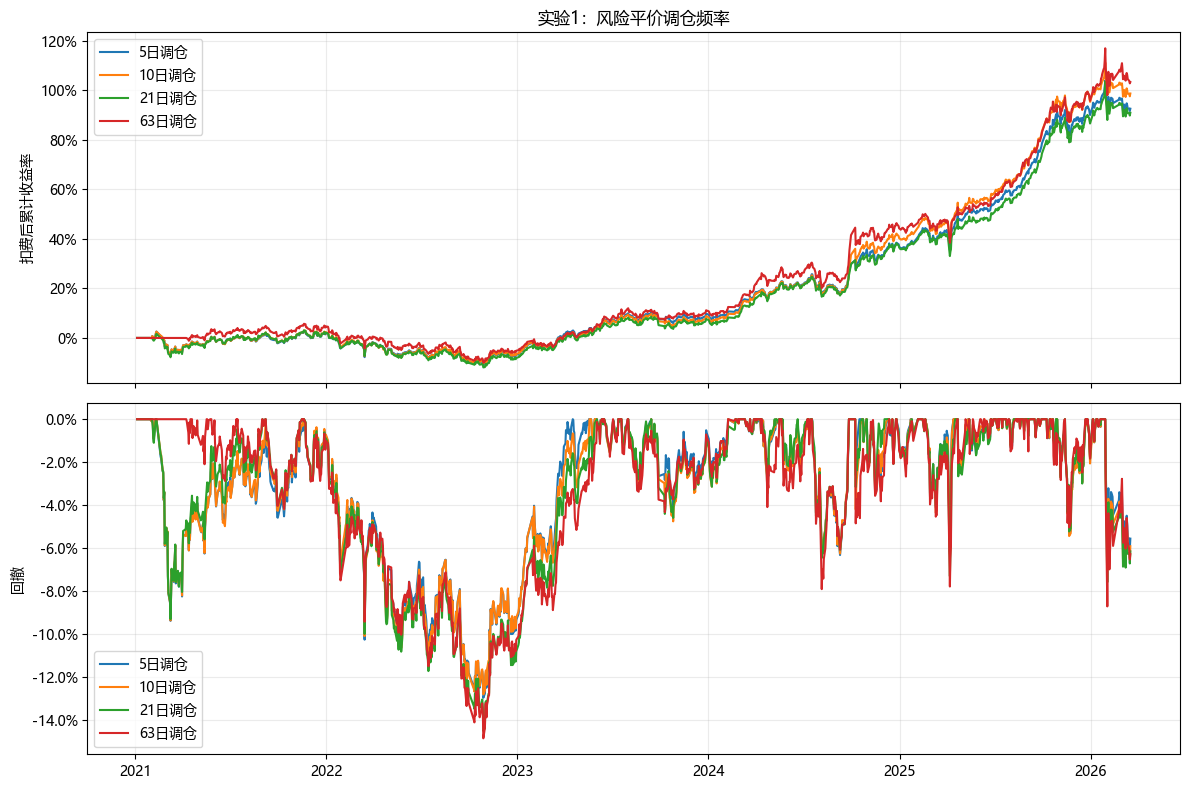

实验1最优： 10日调仓


无保护基线与原策略完全一致


In [5]:
frequency_runs = {f"{n}日调仓": run_case(n) for n in REBALANCE_INTERVALS}
frequency_table = table_for(frequency_runs)
best_frequency_label = best_label(frequency_table)
BEST_INTERVAL = frequency_runs[best_frequency_label]["interval"]
report(frequency_runs, frequency_table, "实验1：风险平价调仓频率", "experiment1")
print("实验1最优：", best_frequency_label)

# 无保护策略必须与原公共策略逐日净值、现金和持仓完全一致。
baseline = frequency_runs[best_frequency_label]
original = Engine(
    Account(INITIAL_CASH, SYMBOLS),
    SimBroker(source, DATA_START, DATA_END, SYMBOLS, execution_price="close",
              commission_rate=COMMISSION_RATE, minimum_commission=MINIMUM_COMMISSION),
    PeriodicAllocationStrategy("risk_parity", SYMBOLS, PERIOD, BEST_INTERVAL),
    ANNUAL_DAYS, signal_timing="same_close")
pd.testing.assert_frame_equal(baseline["ledger"], original.run())
print("无保护基线与原策略完全一致")


## 实验2：止损

使用实验1最优间隔，比较无止损、5%、10%、15%固定止损，不设止盈。


,调仓间隔,止损比例,止盈比例,累计收益率,年化波动率,最大回撤,简化夏普,交易费用,成交笔数,止损次数,止盈次数,首次建仓日
无止损,10,无,无,98.73%,11.07%,12.81%,1.2989,"3,027.05",372,0,0,2021-02-01 00:00:00
5%止损,10,5.00%,无,98.44%,10.58%,12.98%,1.3511,"3,899.44",386,17,0,2021-02-01 00:00:00
10%止损,10,10.00%,无,97.39%,10.89%,13.07%,1.3055,"3,275.28",378,6,0,2021-02-01 00:00:00
15%止损,10,15.00%,无,92.58%,11.01%,14.99%,1.2478,"3,075.78",374,2,0,2021-02-01 00:00:00


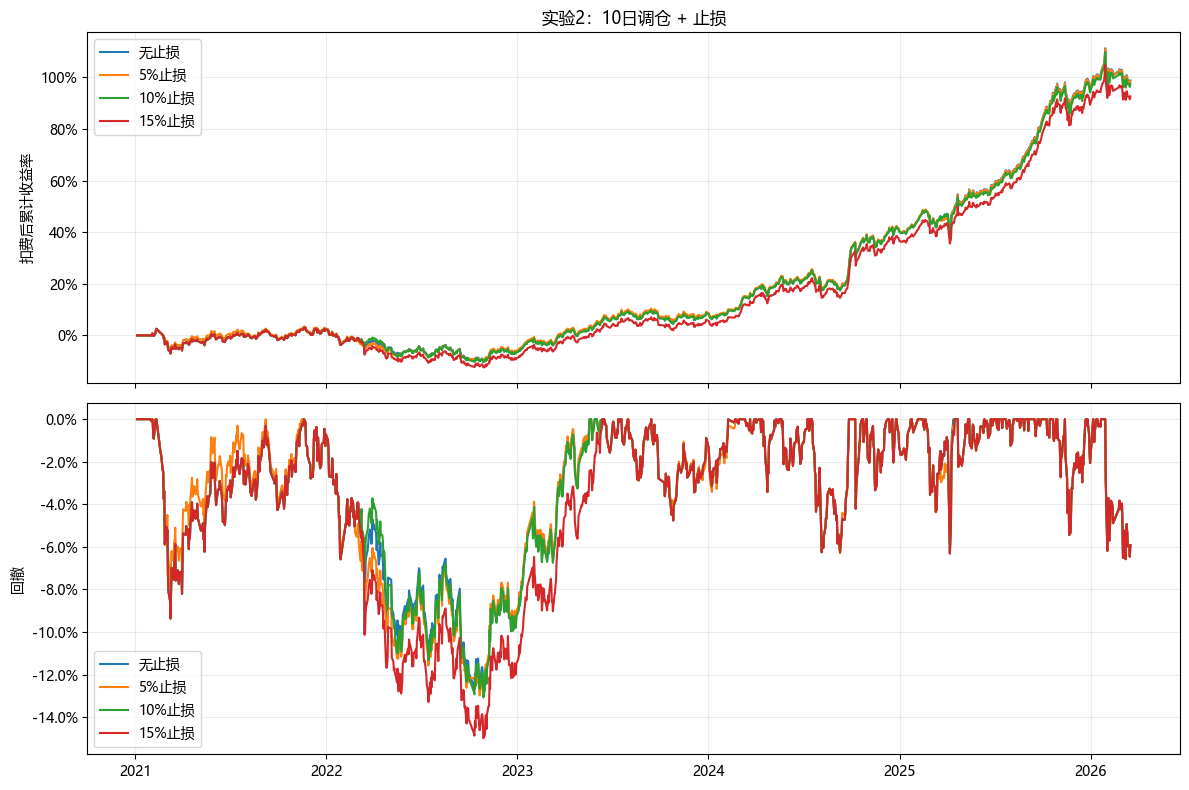

实验2最优： 10 日调仓， 5%止损


In [6]:
stop_runs = {threshold_label(s, "止损"): run_case(BEST_INTERVAL, stop_loss=s)
             for s in STOP_LOSSES}
stop_table = table_for(stop_runs)
best_stop_label = best_label(stop_table)
BEST_STOP = stop_runs[best_stop_label]["stop_loss"]
report(stop_runs, stop_table, f"实验2：{BEST_INTERVAL}日调仓 + 止损", "experiment2")
print("实验2最优：", BEST_INTERVAL, "日调仓，", best_stop_label)
if None in STOP_LOSSES:
    pd.testing.assert_frame_equal(stop_runs["无止损"]["ledger"], baseline["ledger"])


## 实验3：止盈

固定前两步最优间隔及止损，比较不止盈、10%、20%、30%固定止盈。


,调仓间隔,止损比例,止盈比例,累计收益率,年化波动率,最大回撤,简化夏普,交易费用,成交笔数,止损次数,止盈次数,首次建仓日
无止盈,10,5.00%,无,98.44%,10.58%,12.98%,1.3511,"3,899.44",386,17,0,2021-02-01 00:00:00
10%止盈,10,5.00%,10.00%,70.82%,9.56%,8.99%,1.1699,"6,605.25",424,33,27,2021-02-01 00:00:00
20%止盈,10,5.00%,20.00%,85.01%,9.96%,12.98%,1.2877,"5,060.41",404,27,9,2021-02-01 00:00:00
30%止盈,10,5.00%,30.00%,105.96%,10.15%,12.98%,1.4764,"4,288.47",392,21,3,2021-02-01 00:00:00


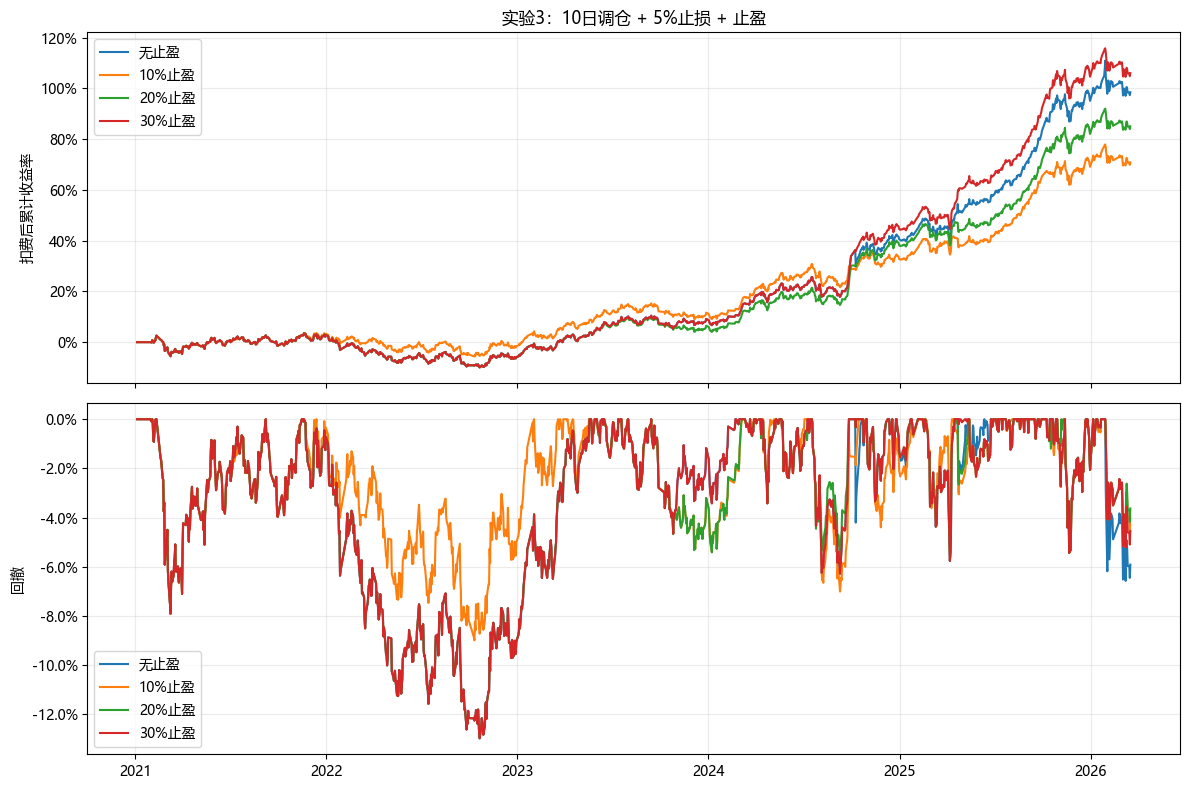

实验3最优： 10 日调仓， 5%止损 ， 30%止盈


In [7]:
profit_runs = {threshold_label(p, "止盈"): run_case(BEST_INTERVAL, BEST_STOP, p)
               for p in TAKE_PROFITS}
profit_table = table_for(profit_runs)
best_profit_label = best_label(profit_table)
BEST_PROFIT = profit_runs[best_profit_label]["take_profit"]
report(profit_runs, profit_table,
       f"实验3：{BEST_INTERVAL}日调仓 + {best_stop_label} + 止盈", "experiment3")
print("实验3最优：", BEST_INTERVAL, "日调仓，", best_stop_label, "，", best_profit_label)
if None in TAKE_PROFITS:
    pd.testing.assert_frame_equal(profit_runs["无止盈"]["ledger"],
                                  stop_runs[best_stop_label]["ledger"])


In [8]:
selected = {"实验1": frequency_runs[best_frequency_label],
            "实验2": stop_runs[best_stop_label],
            "实验3": profit_runs[best_profit_label]}
show_table(table_for(selected))
metadata = {
    "data_start": DATA_START, "data_end": DATA_END, "symbols": SYMBOLS,
    "actual_start": str(baseline["ledger"].index.min().date()),
    "actual_end": str(baseline["ledger"].index.max().date()),
    "initial_cash": INITIAL_CASH, "period": PERIOD,
    "commission_rate": COMMISSION_RATE, "minimum_commission": MINIMUM_COMMISSION,
    "best_interval": BEST_INTERVAL, "best_stop_loss": BEST_STOP,
    "best_take_profit": BEST_PROFIT,
    "reference_price": "weighted average buy price, excluding commissions",
    "execution": "same_close daily price samples",
}
(OUTPUT_DIR / "selection.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print("历史样本内逐步选优：", metadata["best_interval"], BEST_STOP, BEST_PROFIT)
print("不是全组合全局最优，也未做样本外检验。结果目录：", OUTPUT_DIR)


,调仓间隔,止损比例,止盈比例,累计收益率,年化波动率,最大回撤,简化夏普,交易费用,成交笔数,止损次数,止盈次数,首次建仓日
实验1,10,无,无,98.73%,11.07%,12.81%,1.2989,"3,027.05",372,0,0,2021-02-01 00:00:00
实验2,10,5.00%,无,98.44%,10.58%,12.98%,1.3511,"3,899.44",386,17,0,2021-02-01 00:00:00
实验3,10,5.00%,30.00%,105.96%,10.15%,12.98%,1.4764,"4,288.47",392,21,3,2021-02-01 00:00:00


历史样本内逐步选优： 10 0.05 0.3
不是全组合全局最优，也未做样本外检验。结果目录： D:\proj\xquant\xquant-learning-sxl\q4\results
